# Savor - Food-intake training pipeline

Estimates how much food each student actually ate from **before/after dinner
plate photos**, then fits a per-category `grams = a·pixels + b` model.

**Data**
- `dataset/dinner-2026-09-25-{train,test}/{pre|post}/*.png` - plate photos (before/after).
- `dataset/db/<name>-<roll>-<split>.jpeg` - face enrollment photos.
- `dataset/menu_config.json` and `dataset/student_history.json` - closed menu and mock taken/wasted history.
- `dataset/train_item_weights.json` - train-only item weights generated from available scale anchors.
- the plates sit on a digital scale - grams are readable in the photo where the display
  is not cropped.

**Closed-set rule:** OpenAI vision grounding and recommendations may only name
dishes on the printed menu; invalid names and units are rejected or repaired.

**Hardware** runs on CPU (no CUDA). OpenAI vision is called once per uncached image;
all results cache to `artifacts/data/`.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "src" / "granica").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from granica.config import ROOT, RUNTIME, set_seed, TRAIN_WEIGHTS_JSON
from granica.menu import load_menu
set_seed()
print("service:", RUNTIME.day_of_week, RUNTIME.meal, "| on", RUNTIME.service_date)
print("device:", RUNTIME.device, "| vlm:", RUNTIME.vlm_model, "| llm:", RUNTIME.llm_model)
print("splits:", RUNTIME.people_ids())


service: FRIDAY DINNER | on 2026-09-25
device: cpu | vlm: gpt-4o | llm: gpt-4o
splits: ['aakarsh-230102122', 'archit-230101010', 'arjun-230102125', 'garv-230104044', 'kunj-230103056', 'mithil-230103077', 'nitish-230103022', 'takshay-230102111', 'vaibhav-230103066']


## Training split - before and after photographs

These are every actual paired plate photo from the configured **train split**.
The separate held-out test split is used only in notebook 2.

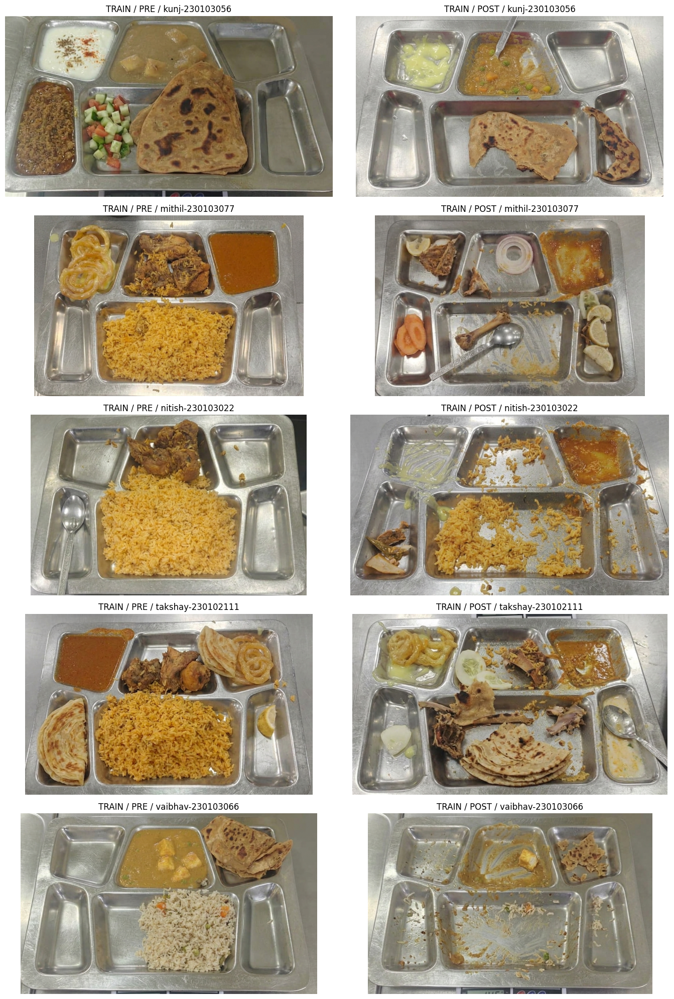

training paired students: 5 | photos: 10


In [2]:
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

train_pre = {p.stem: p for p in RUNTIME.plate_images("train", "pre")}
train_post = {p.stem: p for p in RUNTIME.plate_images("train", "post")}
train_ids = sorted(set(train_pre) | set(train_post))
fig, axes = plt.subplots(max(1, len(train_ids)), 2, figsize=(14, 4 * max(1, len(train_ids))), squeeze=False)
for row, person_id in enumerate(train_ids):
    for col, stage in enumerate(("pre", "post")):
        path = (train_pre if stage == "pre" else train_post).get(person_id)
        ax = axes[row][col]
        if path:
            ax.imshow(Image.open(path)); ax.set_title(f"TRAIN / {stage.upper()} / {person_id}")
        else:
            ax.text(0.5, 0.5, "no paired photo", ha="center", va="center")
        ax.axis("off")
plt.tight_layout(); display(fig); plt.close(fig)
print("training paired students:", len(train_ids), "| photos:", len(train_pre) + len(train_post))


## Step 1 - Menu config (closed set)

`dataset/menu_config.json` is a hand-transcribed copy of the printed menu. Each dish
is tagged with a **category** and a **countable unit -> grams** table. Only these
dish names may appear anywhere downstream.

In [3]:
menu = load_menu()
from granica.menu import menu_for, menu_items

dinner = menu_for(menu, RUNTIME.day_of_week, RUNTIME.meal)
print(f"{RUNTIME.day_of_week} {RUNTIME.meal}: {len(dinner)} dishes")
for e in dinner:
    print(f"  {e['name']:28s} {e['category']:13s} units={e['units']}")
print("\nwhitelist:", menu_items(menu, RUNTIME.day_of_week, RUNTIME.meal))


FRIDAY DINNER: 9 dishes
  Chicken Hyderabadi Biryani   rice          units=['katori', 'bowl', 'plate', 'ladle']
  Shahi Paneer                 curry         units=['katori', 'bowl', 'piece', 'ladle']
  Veg pulav                    rice          units=['katori', 'bowl', 'plate', 'ladle']
  Chana Daal                   dal           units=['katori', 'bowl', 'ladle']
  Jalebi rabri                 dessert       units=['piece', 'scoop', 'bowl', 'cup']
  Chutney                      chutney_pickle units=['teaspoon', 'tablespoon', 'katori']
  Lemon Water                  drink         units=['glass', 'cup', 'bottle']
  Plain roti + Butter Roti     bread         units=['roti', 'paratha', 'naan', 'bhature', 'bread_slice']
  Methi Parantha               bread         units=['roti', 'paratha', 'naan', 'bhature', 'bread_slice']

whitelist: ['Chicken Hyderabadi Biryani', 'Shahi Paneer', 'Veg pulav', 'Chana Daal', 'Jalebi rabri', 'Chutney', 'Lemon Water', 'Plain roti + Butter Roti', 'Methi Parantha

## Step 2 - Face identification & DB retrieval

Build a gallery of the 9 students from `dataset/db/*` with InsightFace
`buffalo_l`, then measure:

1. **Verification** - genuine vs impostor cosine similarity + EER threshold.
2. **Rank-1 identification** - each enrollment face -> nearest gallery person.

Plate photos contain no faces, so a plate is attributed to its student via the
filename stem `<name>-<roll>`. `identify()` is demo'd on face photos; any future
ID photo behaves identically.


In [4]:
from granica.faceid import FaceIdentifier
from granica.io_utils import load_json

ident = FaceIdentifier()
metrics_path = ROOT / "artifacts/faces/face_metrics.json"
if not ident.load_gallery() or not metrics_path.exists():
    ident.build_gallery(RUNTIME.db_dir)
    rep = ident.evaluate(RUNTIME.db_dir)
else:
    rep = load_json(metrics_path)
    print("loaded cached train gallery and face metrics")
print("gallery persons:", len(ident.names))
for k in ["gallery_size", "rank1_accuracy_mean", "rank1_total",
          "verification_same_mean", "verification_diff_mean", "eer_threshold", "eer"]:
    print(f"  {k}: {rep[k]}")


C:\Users\Arjun\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\Arjun\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


loaded cached train gallery and face metrics
gallery persons: 8
  gallery_size: 8
  rank1_accuracy_mean: 0.875
  rank1_total: 8
  verification_same_mean: 0.6494570970535278
  verification_diff_mean: 0.10690446887618607
  eer_threshold: 0.542639434337616
  eer: 0.0


In [5]:
from pathlib import Path
ident = FaceIdentifier()
ident.load_gallery()
sample = sorted(RUNTIME.db_dir.glob("*.jpeg"))[0]
res = ident.identify(sample)
print("face photo ->", res["best"], "score", round(res["score"], 3),
      "rank-1 candidates:", [r["name"] for r in res["topk"]])
from granica.faceid import parse_plate_filename, parse_db_filename
print("plate stem ->", parse_plate_filename("arjun-230102125"))
print("db stem   ->", parse_db_filename("arjun-230102125-train.jpeg"))


C:\Users\Arjun\anaconda3\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


face photo -> aakarsh score 0.617 rank-1 candidates: ['aakarsh', 'vaibhav', 'garv']
plate stem -> ('arjun', '230102125')
db stem   -> ('arjun-230102125-train.jpeg', 'unknown', 'train')


### Held-out face similarity against the train gallery

Each held-out test face is compared only with train enrollment images. The test
target is never included as a bar in its own comparison.

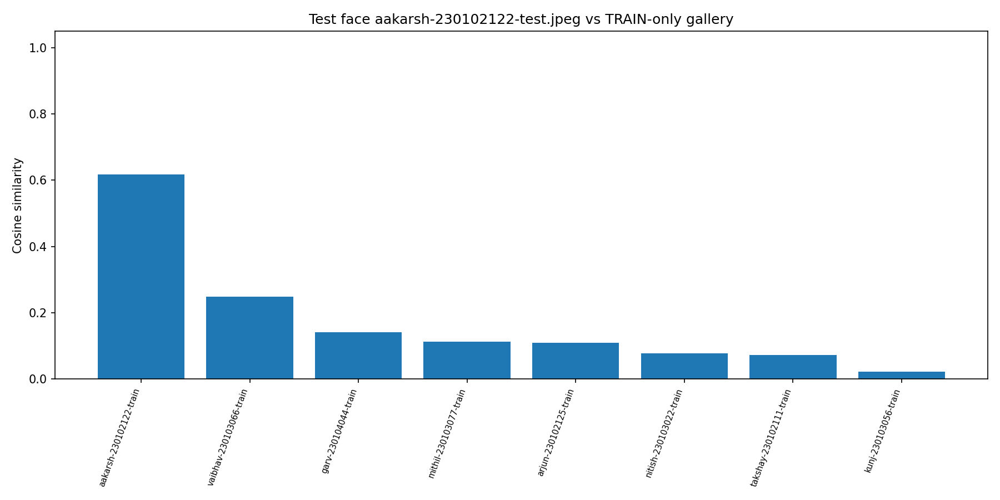

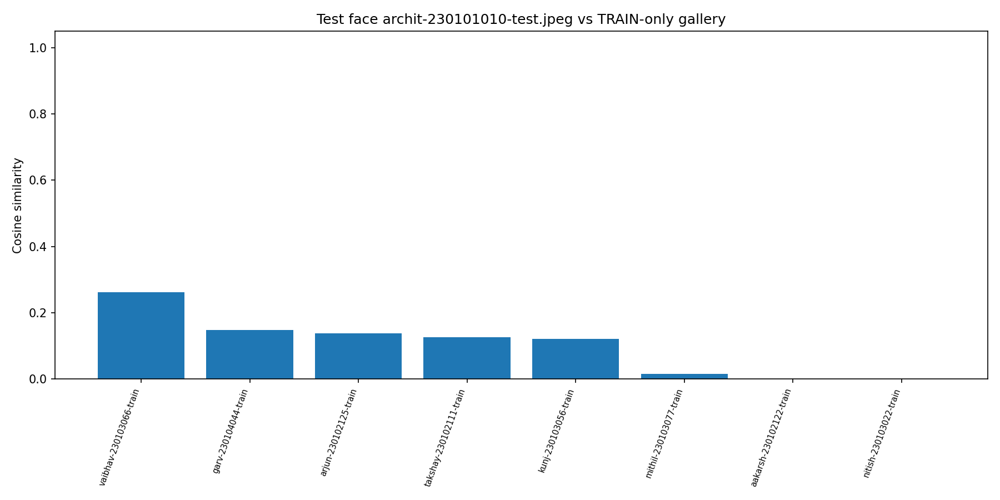

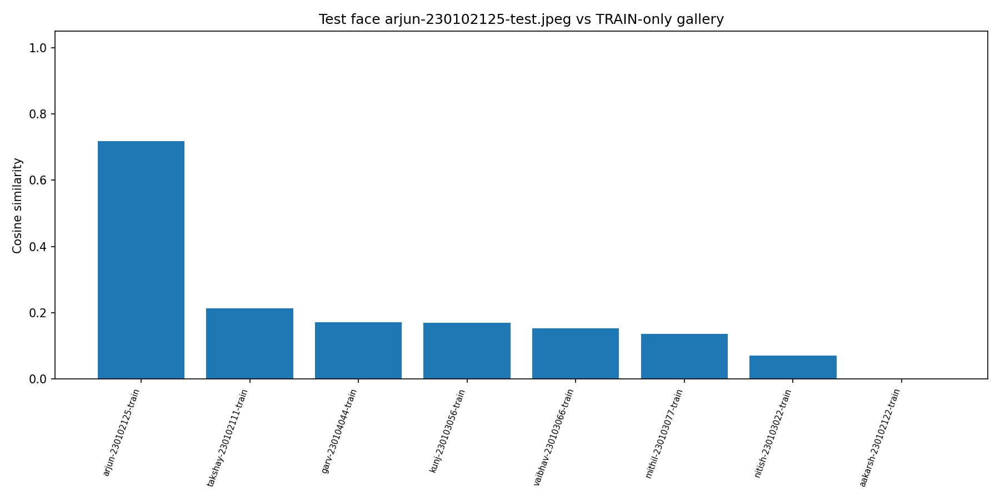

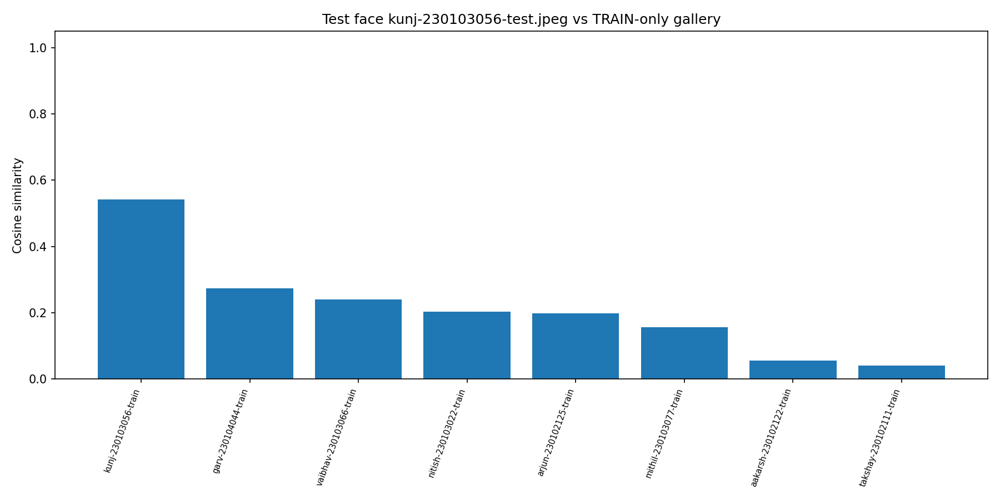

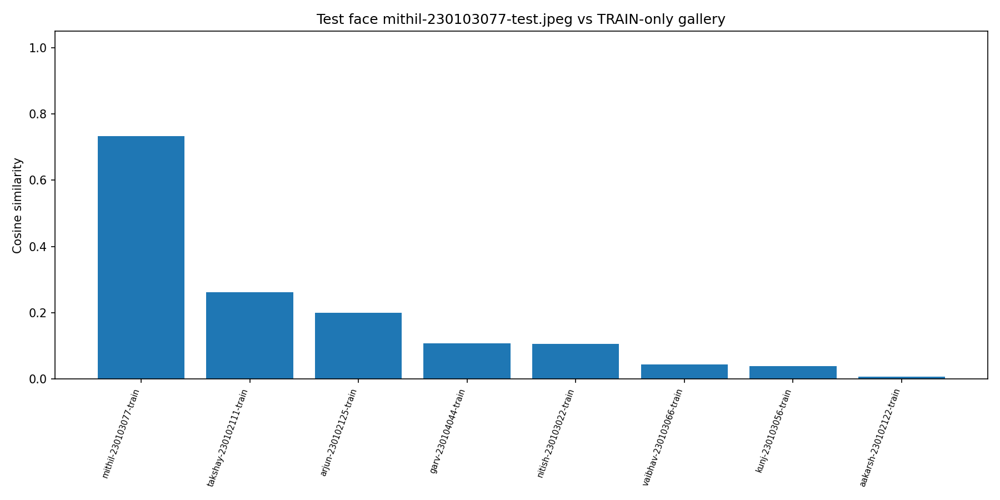

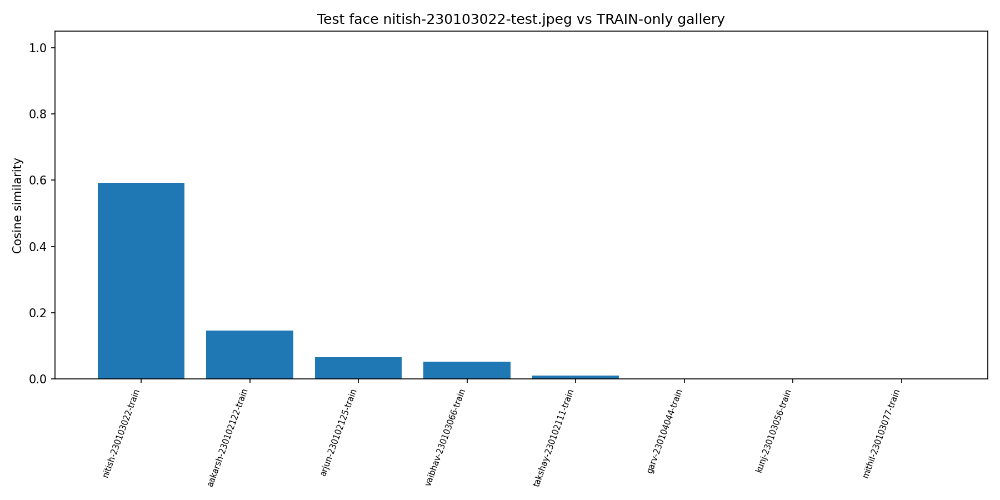

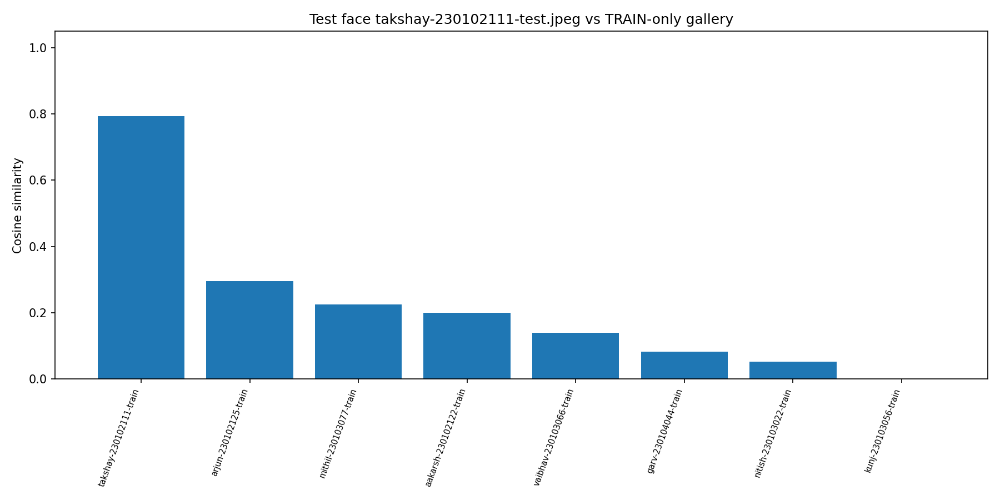

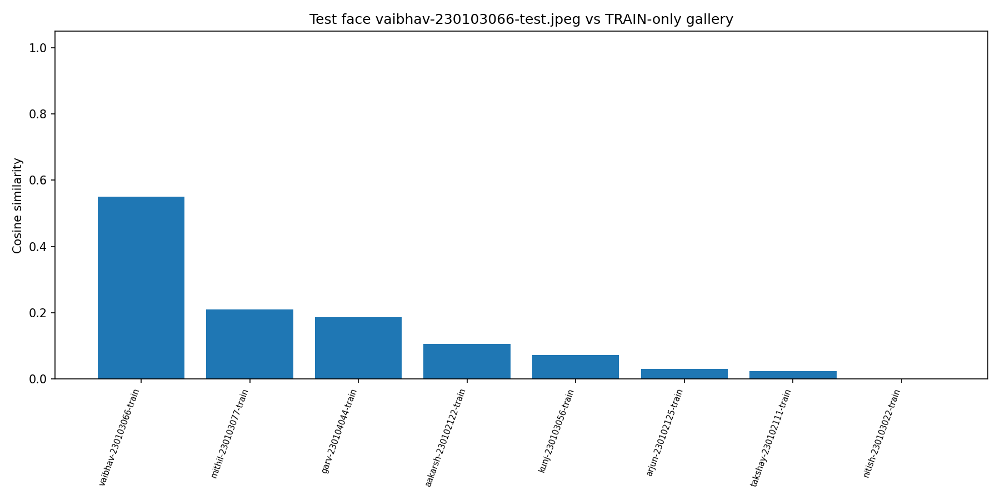

test queries compared with train-only gallery: 8


In [6]:
from visualize_outputs import _face_similarity
face_similarity_paths = _face_similarity()
for path in face_similarity_paths:
    display(Image.open(path))
print("test queries compared with train-only gallery:", len(face_similarity_paths))


## Step 3 - OpenAI vision grounding (closed set)

OpenAI vision inspects overlapping top and bottom crops of each wide source
photo. Crop boxes are mapped back to native full-image pixels and duplicates in
the overlap are removed. Every image stays restricted to the printed menu.
Results are cached to `artifacts/data/groundings.json`.

In [7]:
from granica.grounding import OpenAIGrounding, load_groundings

gmodel = OpenAIGrounding()
images = [p for stage in ("pre", "post") for p in RUNTIME.plate_images("train", stage)]
whitelist = menu_items(menu, RUNTIME.day_of_week, RUNTIME.meal)

dropped_total = 0
for p in images:
    dropped_total += gmodel.ground(p, whitelist)["dropped"]
print(f"grounded {len(images)} images; non-menu items dropped: {dropped_total}")

g = load_groundings()
k = str(images[0])
print("sample", Path(k).name, "->", [(b["item"], b["bbox"]) for b in g[k]["items"]])


grounded 10 images; non-menu items dropped: 11
sample kunj-230103056.png -> [('Shahi Paneer', [303, 12, 700, 200]), ('Methi Parantha', [510, 189, 874, 539]), ('Chutney', [12, 12, 295, 173]), ('Chana Daal', [12, 217, 290, 403])]


## Step 4 - SAM segmentation inside each box

MobileSAM receives the full source image plus each corrected native-pixel food
box. Its mask is clipped to that box before pixels are counted; an empty mask is
recorded as zero, never replaced with a color-based guess. Each mask gets a
category label in the saved visualization.

In [8]:
from granica.segmentation import SAMSegmenter, load_segmentation
from granica.grounding import load_groundings

seg = SAMSegmenter()
g = load_groundings()
images = [p for stage in ("pre", "post") for p in RUNTIME.plate_images("train", stage)]
for p in images:
    rec = g.get(str(p), {})
    boxes = [it["bbox"] for it in rec.get("items", [])]
    if boxes:
        seg.segment(p, boxes, labels=[it["item"] for it in rec.get("items", [])])

seg_db = load_segmentation()
k = str(images[0])
print("segmentation for", Path(k).name)
for b in seg_db[k]["boxes"]:
    print(f"  pixels={b.get('pixel_count')} iou={b.get('iou', 0):.2f}")


segmentation for kunj-230103056.png
  pixels=42874 iou=0.00
  pixels=83759 iou=0.00
  pixels=32701 iou=0.00
  pixels=42389 iou=0.00


### Training grounding and segmentation overlays

Each image below is generated from its paired training photo: menu labels appear
on the grounding boxes and on the opaque SAM mask overlay.

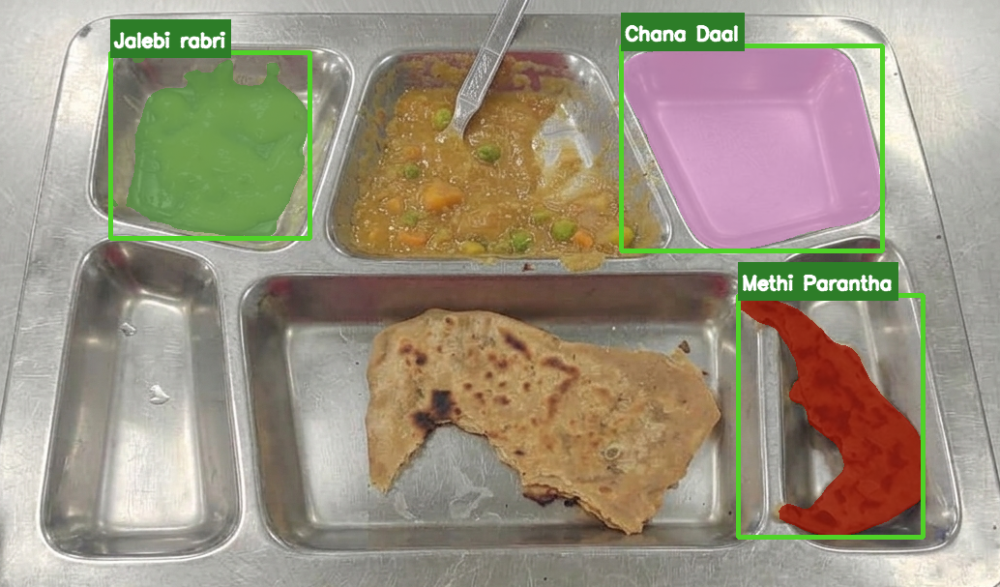

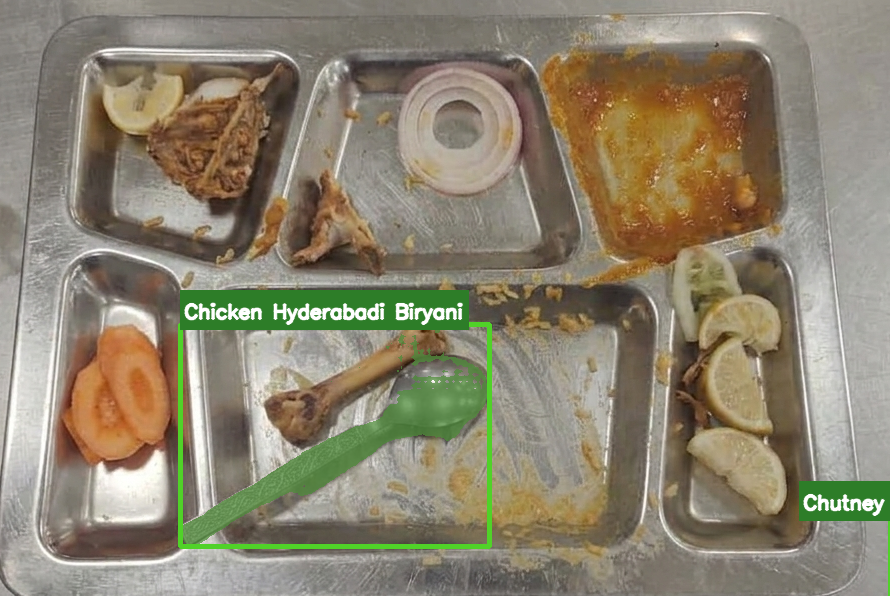

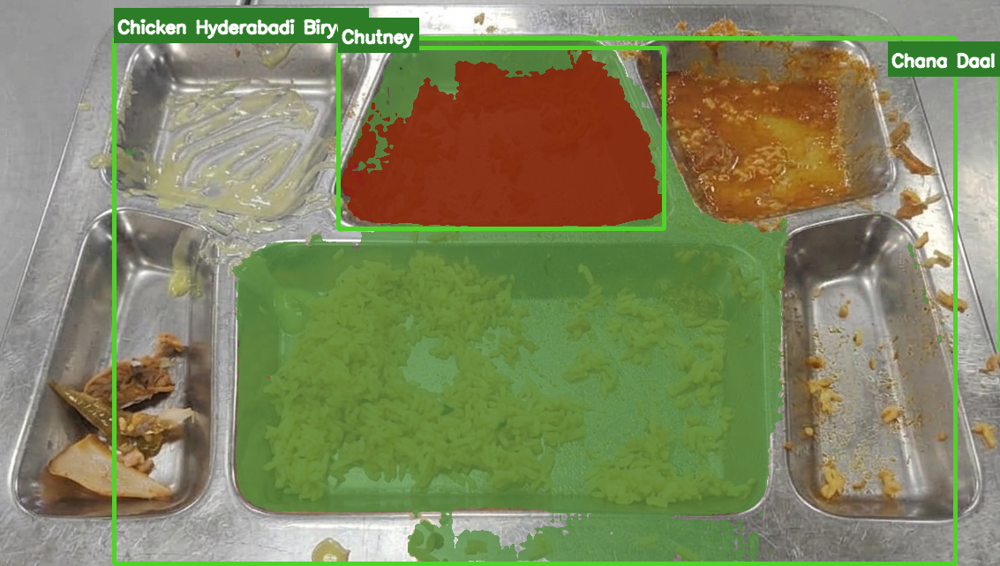

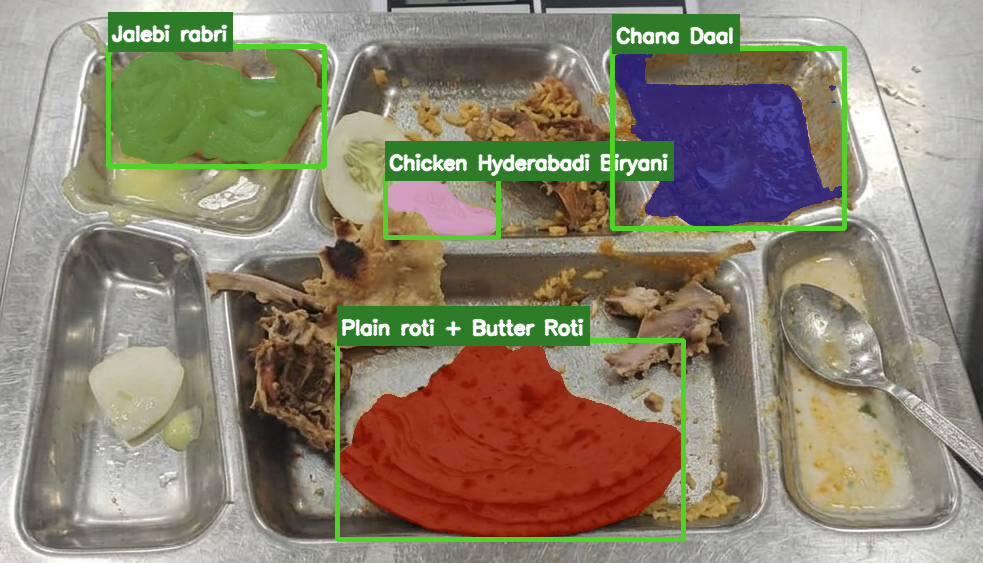

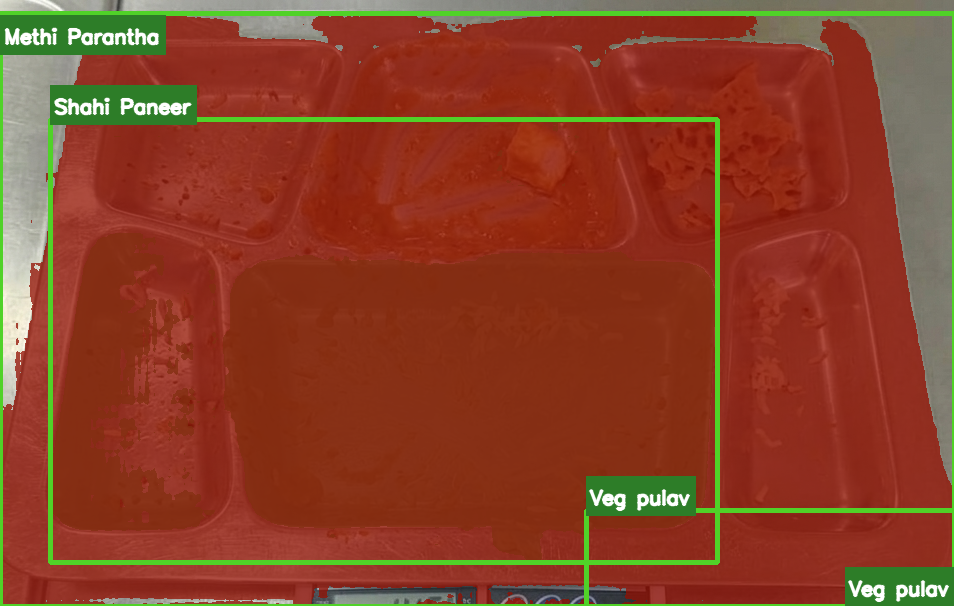

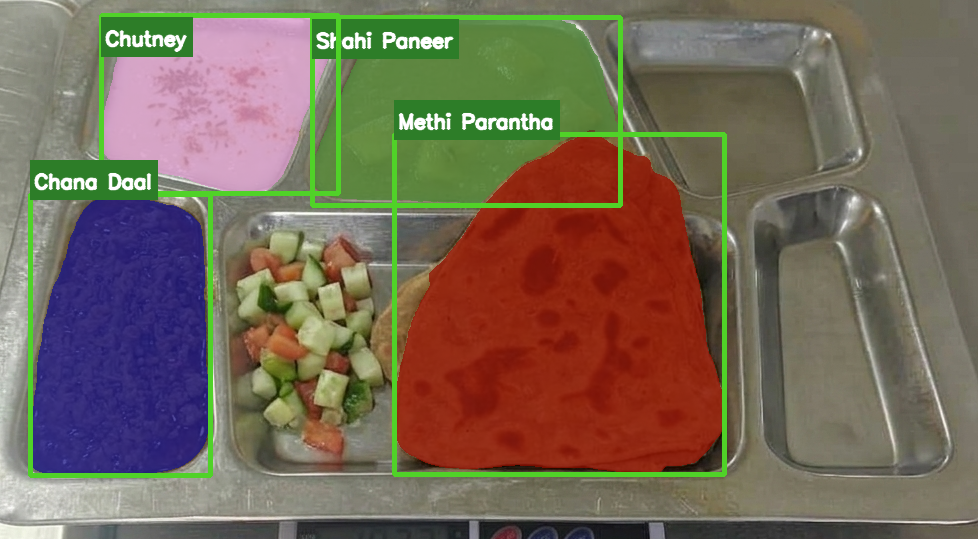

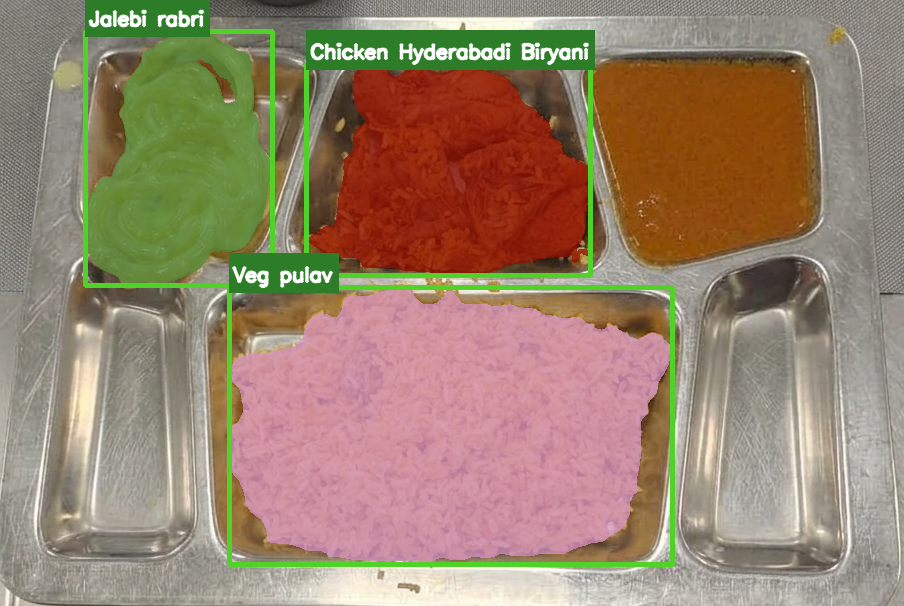

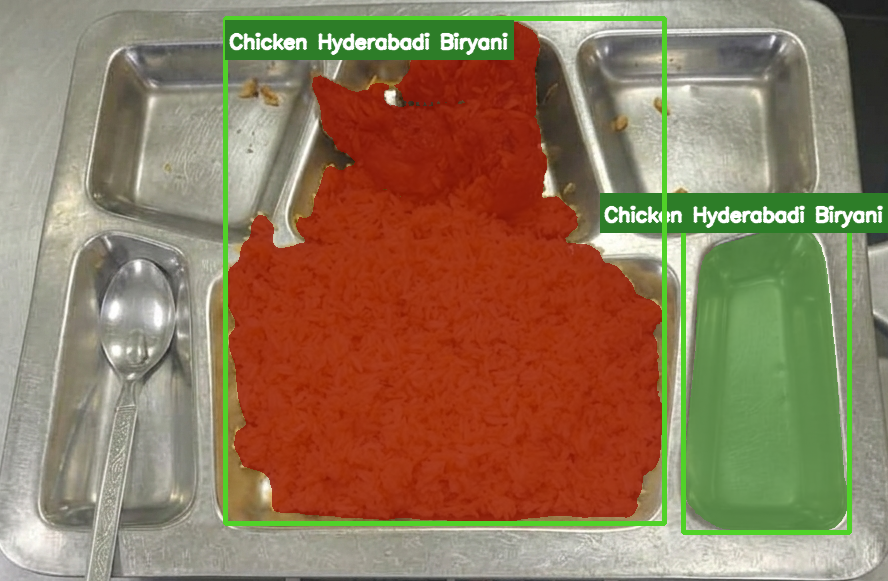

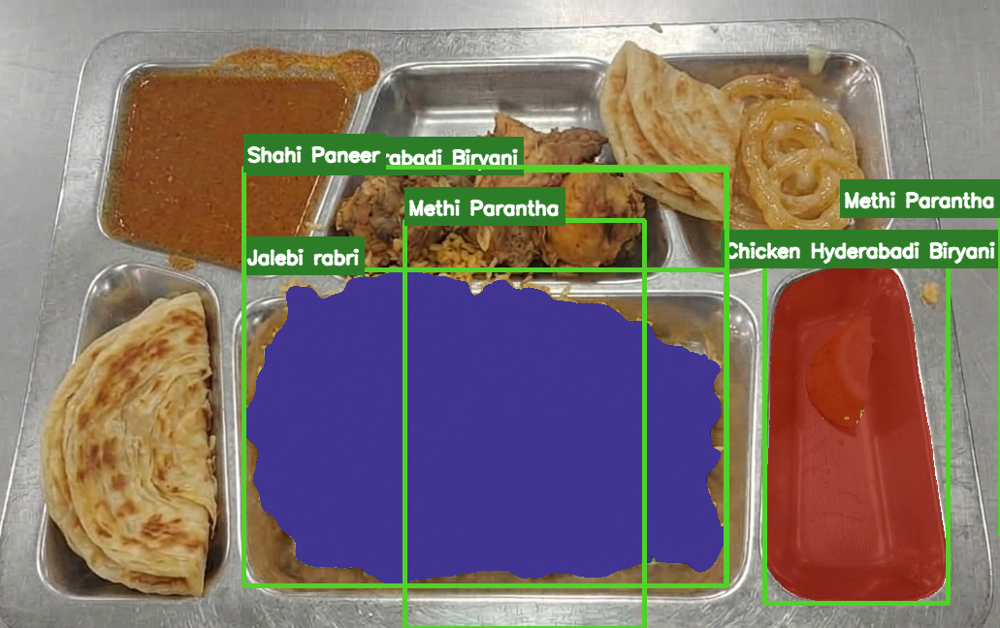

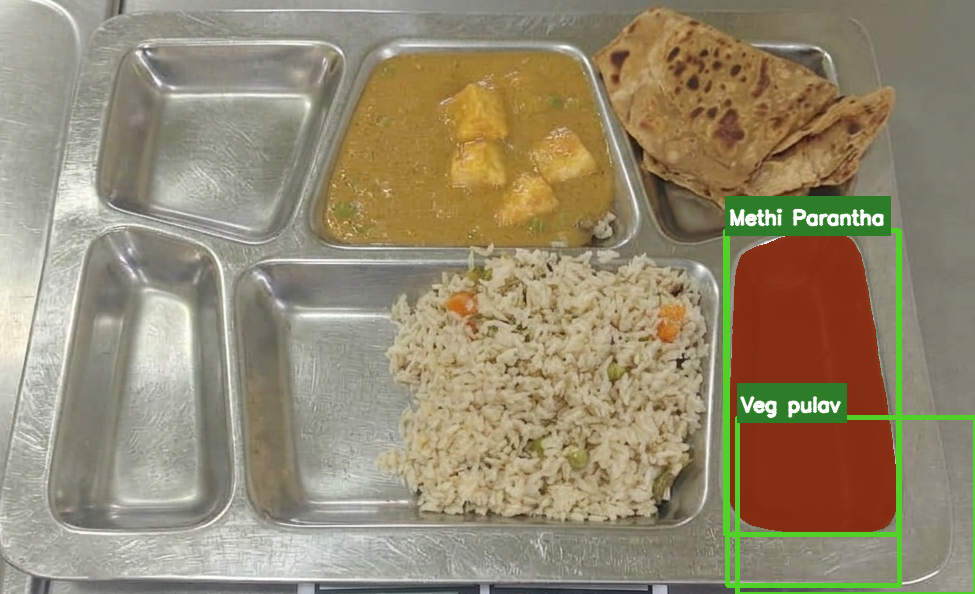

inline train box+mask overlays: 10


In [9]:
from visualize_outputs import _grounding_images
from granica.segmentation import load_segmentation
from granica.grounding import load_groundings

overlay_paths = _grounding_images(load_groundings(), load_segmentation())
train_overlays = [p for p in overlay_paths if Path(p).parent.parent.name == "dinner-2026-09-25-train"]
for path in train_overlays:
    display(Image.open(path))
print("inline train box+mask overlays:", len(train_overlays))


## Step 5 - Training weights and scale anchors

`scripts/analyze_images.py` keeps scale readings separately and creates
train-only item weights from plate totals. Per-item allocations are estimates,
not individually measured weights; the dataset config records this provenance.


In [10]:
import subprocess, sys
from pathlib import Path
from granica.io_utils import load_json

gt_path = ROOT / "artifacts/data/ground_truth_weights.json"
import os
env = os.environ.copy(); env["GRANICA_SPLITS"] = "train"
subprocess.run([sys.executable, str(ROOT / "scripts/analyze_images.py")], check=True, env=env)

gt = load_json(gt_path)
pl = gt["plates"]["train/pre/kunj-230103056"]
print("kunj train/pre total:", pl["total_grams"], "g (scale anchor:", pl["anchored"], ")")
for it in pl["items"]:
    print(f"  {it['item']:26s} {it['category']:11s} px={it['pixels']:5d}  g={it['grams']}")
print("\nbaked plates:", len(gt["plates"]))


kunj train/pre total: 663.0 g (scale anchor: 1073 )
  Shahi Paneer               curry       px=42874  g=183.9
  Methi Parantha             bread       px=83759  g=224.5
  Chutney                    chutney_pickle px=32701  g=77.9
  Chana Daal                 dal         px=42389  g=176.7

baked plates: 10


## Step 6 - Fit per-category pixel->weight models

Fit `grams = a*pixels + b` for every category present in the training plates.
Categories below `min_points_per_category` are pooled into a shared `__global__`
fallback so the model is never empty.


In [11]:
from granica.weights import fit_models

models = fit_models(gt)
print(f"{'category':14s} {'n':>3s} {'slope':>11s} {'intc':>9s} {'R2':>7s} {'MAE':>7s} used")
for c, m in models.items():
    print(f"{c:14s} {m['n']:3d} {m['slope']:11.6f} {m['intercept']:9.3f} {m['r2']:7.3f} {m['mae']:7.2f} {m['used']}")


category         n       slope      intc      R2     MAE used
bread            4    0.001099   146.870   0.898   56.39 True
chutney_pickle   1    0.000000    77.900   0.000    0.00 False
curry            3    0.000000   337.633   0.000  102.49 False
dal              2    0.000000   213.900   0.000   37.20 False
dessert          2    0.000000   109.300   0.000   19.80 False
rice             4    0.003811    49.425   0.933   40.70 True
__global__       8    0.001517   137.815   0.000   83.08 True


### Per-category regression plots

These figures show the train points and the fitted pixel-to-grams line for each
food category. Per-item labels are scale-anchored plate allocations, so the plots
are training diagnostics rather than independent measured-item accuracy.

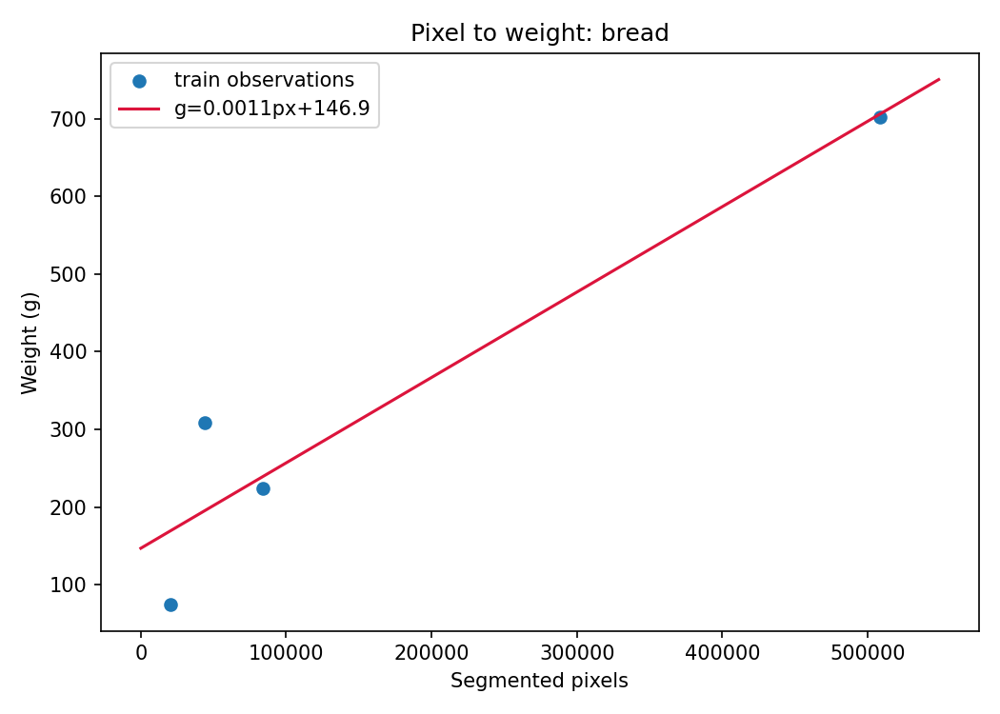

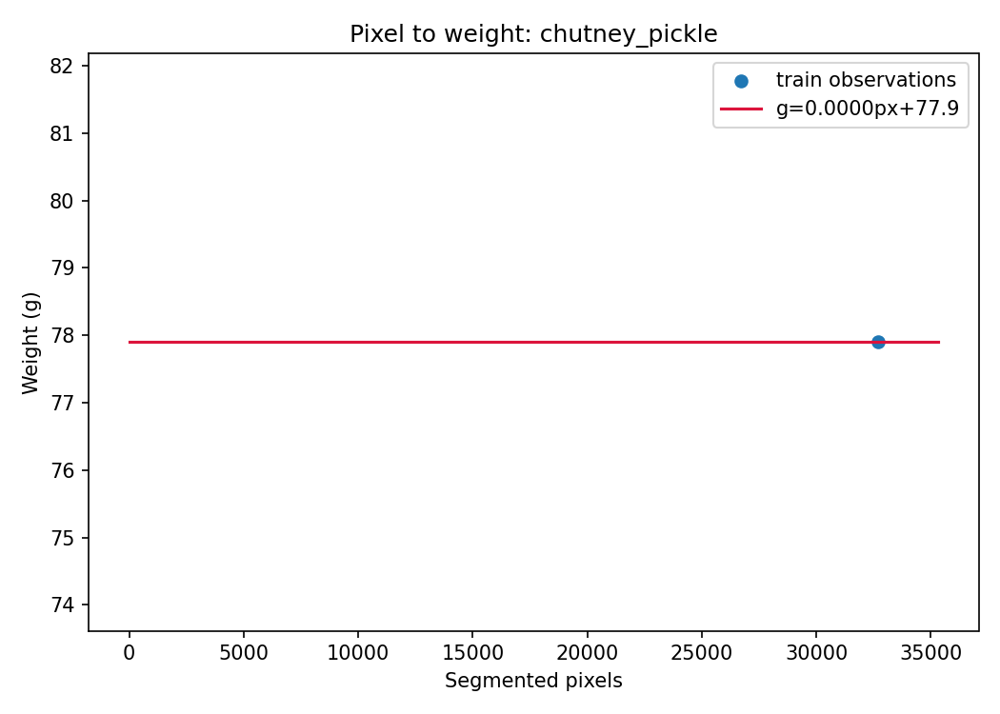

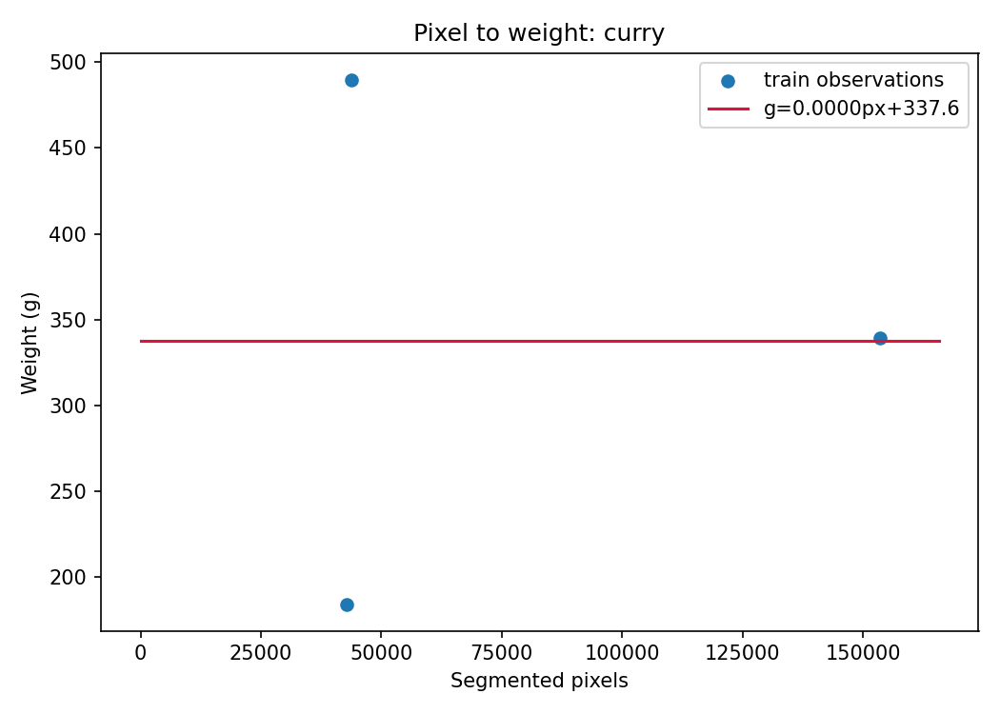

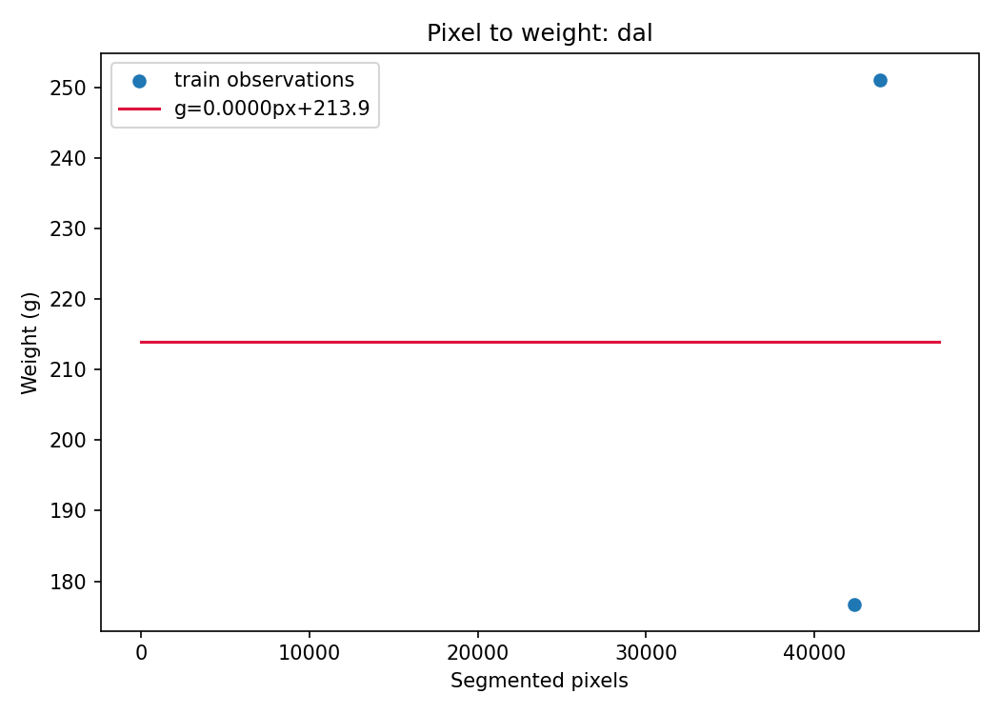

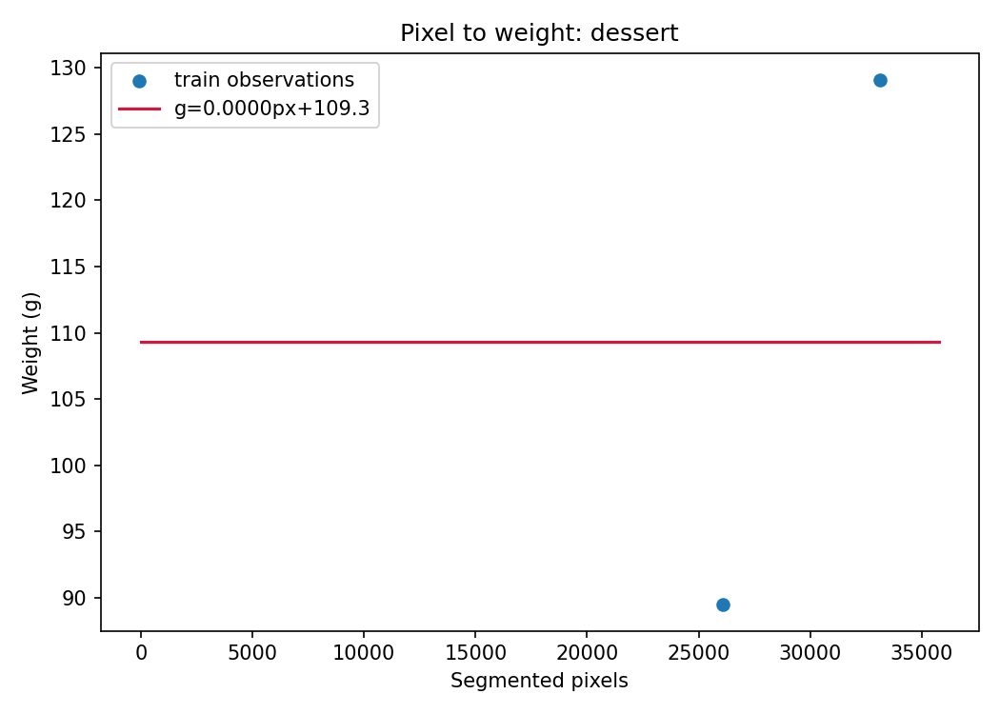

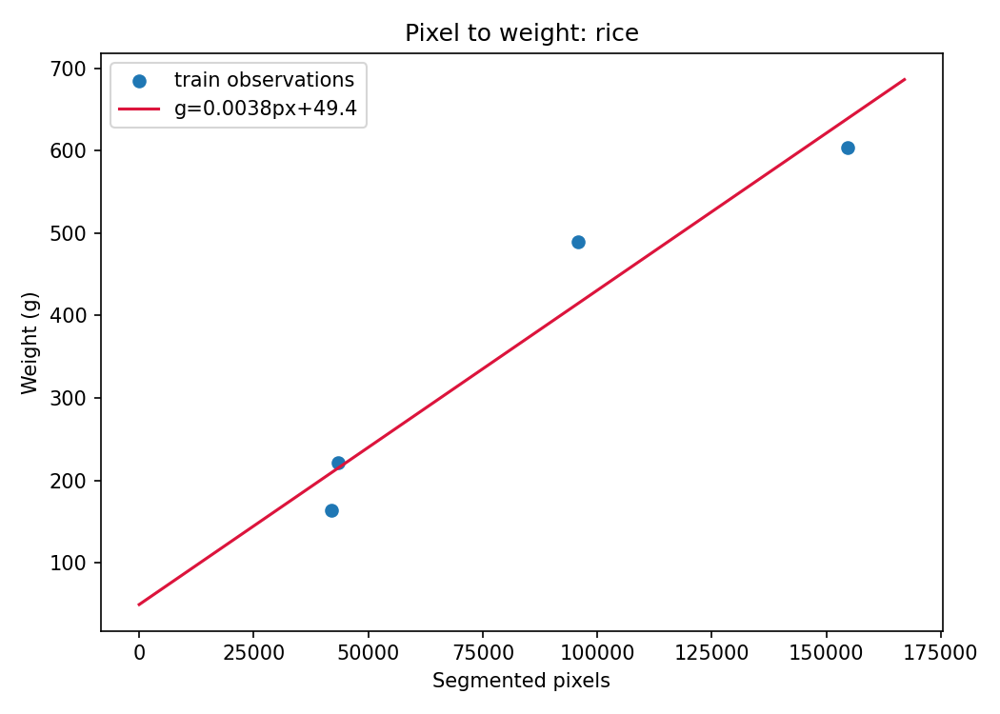

regression plots: 6


In [12]:
from visualize_outputs import _regressions
regression_paths = _regressions(gt, models)
for path in regression_paths:
    display(Image.open(path))
print("regression plots:", len(regression_paths))


## Step 7 - Training fit check

This MSE is reported on the scale-anchored training examples used to fit the
line. It is a fit diagnostic, not held-out accuracy; the held-out test photos
and any readable scale totals are handled in notebook 2.


In [13]:
points = [(it["pixels"], it["grams"], it["category"])
          for p in gt["plates"].values() if p["split"] == "train" and p.get("anchored") is not None
          for it in p["items"]]
errors = []
for pixels, grams, category in points:
    model = models.get(category, models.get("__global__"))
    errors.append((model["slope"] * pixels + model["intercept"] - grams) ** 2)
train_mse = sum(errors) / len(errors) if errors else float("nan")
print(f"scale-anchored train items: {len(points)}")
print(f"training fit MSE: {train_mse:.2f} g^2 (not test accuracy)")


scale-anchored train items: 16
training fit MSE: 5079.01 g^2 (not test accuracy)


## Step 8 - Consumption history & people store

Food eaten = pre_total - post_total. This notebook writes training-split
consumption; the inference notebook handles held-out test plates.


In [14]:
from granica.weights import build_consumption

people = build_consumption(gt, {}, out_path=ROOT / "artifacts/data/people.json")
kunj = people["people"]["kunj-230103056"]
print("kunj meals:", len(kunj["meals"]))
for m in kunj["meals"]:
    print(f"  {m['split']} {m['stage']:5s} total={m['total_grams']} consumed={m.get('consumed_grams')}")


kunj meals: 2
  train pre   total=663.0 consumed=None
  train post  total=415.0 consumed=None


## Summary

- `dataset/menu_config.json` - closed menu + unit->grams.
- `dataset/student_history.json` - mock meals with served, taken and wasted grams.
- `dataset/train_item_weights.json` - train-only per-item labels and provenance.
- `artifacts/data/groundings.json` - OpenAI vision labels (cached).
- `artifacts/data/segmentation.json` - SAM pixel counts (cached).
- `artifacts/data/ground_truth_weights.json` - train labels with scale readings kept separately.
- `artifacts/weights/weight_models.json` - fitted `grams = a*pixels + b` per category.
- `artifacts/data/people.json` - training-split intake calculation.

Open `notebooks/2_inference_pipeline.ipynb` for held-out test results and
several personalized recommendation examples.